В этом документе рассматриваются основные конструкции PyTorch на примере задачи классификации набора данных Fashion MNIST. Основная цель лабораторной работы – знакомство с фреймворком PyTorch. 

Лабораторная работа основана на материалах, представленных на официальном сайте https://pytorch.org. Оригинальная версия материала доступна по ссылке https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html. Подробная документация PyTorch доступна по ссылке https://pytorch.org/docs/stable/index.html.

### Используемые модули

In [22]:
# Основной модуль PyTorch
import torch

# Модуль, содержащий классы и функции, использующиеся для построения нейронных сетей
from torch import nn 

# Класс, предоставляющий iterable вокруг набора данных (torch.utils.data.Dataset)
from torch.utils.data import DataLoader 

# Встроенные наборы данных для задач, связанных с изображениями, включающие Fashion MNIST
from torchvision import datasets

# Класс, преобразующий изображение PIL или массив numpy в torch.Tensor
from torchvision.transforms import ToTensor

#Вспомогательный модуль
import matplotlib.pyplot as plt

In [23]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Default Device: {torch.get_default_device()}")

PyTorch Version: 2.9.1+cu128
CUDA Available: True
Default Device: cpu


### Загрузка набора данных
Набор данных Fashion MNIST может быть получен через datasets.FashionMNIST.

In [24]:
# Загрузка тренировочного набора данных
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Загрузка тестового набора данных
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

Набор данных: <class 'torchvision.datasets.mnist.FashionMNIST'>
Длина: 60000
Состоит из: <class 'tuple'>, включающих в себя 
<class 'torch.Tensor'> (изображение) 
 и <class 'int'> (номер класса изображения)
Размерность изображения: torch.Size([1, 28, 28])
Пример изображения:


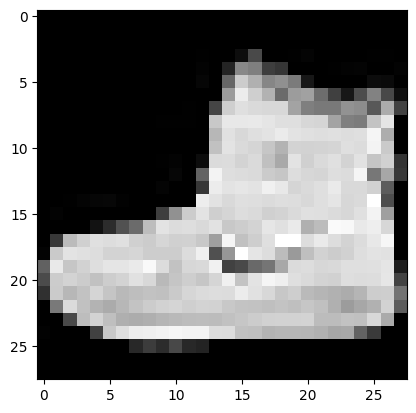

In [25]:
print('Набор данных: ' + str(type(training_data)))
print('Длина: ' + str(len(training_data)))
print('Состоит из: ' + str(type(training_data[0])) + 
      ', включающих в себя \n' + str(type(training_data[0][0])) + ' (изображение) ' +
      '\n и ' + str(type(training_data[0][1])) + ' (номер класса изображения)')
print('Размерность изображения: ' + str(training_data[0][0].shape))
print('Пример изображения:')
plt.imshow(training_data[0][0].squeeze(), cmap = 'gray')

### Использование DataLoader

Класс DataLoader используется для итерации по набору данных. DataLoader поддерживает такие операции, как разделение на подвыборки, перемешивание и параллельную загрузку данных. В этой работе DataLoader используется для разделения набора данных на подвыборки размера 64.

In [26]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Размерность X [N, C, H, W]: {X.shape}")
    print(f"Размерность y: {y.shape}, тип: {y.dtype}")
    break

Размерность X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Размерность y: torch.Size([64]), тип: torch.int64


### Создание модели

PyTorch может использовать видеокарты с поддержкой CUDA, доступность которых проверяется через функцию torch.cuda.is_available().

Модели в PyTorch представлены классами, которые наследуют базовый класс nn.Module.
<br>Каждая можель должна иметь функцию forward, определяющую расчёты, производящиеся при использовании модели.
<br>Используемые при расчётах слои создаются в конструкторе \_\_init__.
<br>Для удобства расчётов несколько стоящих подряд слоёв могут быть объединены в одну переменную с помощью nn.Sequential.

In [27]:
# Использование устройство CUDA, если оно доступно
device = "cpu"
print(f"Используется устройство: {device}")

# Создание модели
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__() # Перед созданием слоёв выполняется вызов конструктора родительского класса
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Используется устройство: cpu
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Обучение модели

При обучении модели используется функция потерь nn.CrossEntropyLoss и метод оптимизации torch.optim.SGD.

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

При обучении модель определяет классы изображений в тренировочном наборе данных (разделённом на подвыборки), после чего выполняет обратное распространение ошибки для корректировки параметров модели.

In [29]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train() # Перевод модели в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device) # Данные и модель должны находиться на одном устройстве

        # Расчёт потерь
        pred = model(X)
        loss = loss_fn(pred, y)

        # Обратное распространение ошибки
        optimizer.zero_grad() # Обнуление ранее рассчитанных градиентов
        loss.backward() # Расчёт новых градиентов
        optimizer.step() # Изменение весов (шаг обучения)

        if batch % 100 == 0: # Вывод информации каждые 100 итераций
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

Также может быть определена функция тестирования для проверки качества обучения.

In [30]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() # Перевод модели в режим тестирования
    test_loss, correct = 0, 0
    with torch.no_grad(): # Отключение расчёта градиентов для ускорения работы
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [31]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299303  [    0/60000]
loss: 2.279980  [ 6400/60000]
loss: 2.261800  [12800/60000]
loss: 2.255756  [19200/60000]
loss: 2.233922  [25600/60000]
loss: 2.214854  [32000/60000]
loss: 2.218375  [38400/60000]
loss: 2.183249  [44800/60000]
loss: 2.183501  [51200/60000]
loss: 2.146049  [57600/60000]
Test Error: 
 Accuracy: 41.8%, Avg loss: 2.137871 

Epoch 2
-------------------------------
loss: 2.151596  [    0/60000]
loss: 2.136555  [ 6400/60000]
loss: 2.071655  [12800/60000]
loss: 2.090772  [19200/60000]
loss: 2.034626  [25600/60000]
loss: 1.975672  [32000/60000]
loss: 2.006359  [38400/60000]
loss: 1.920155  [44800/60000]
loss: 1.933136  [51200/60000]
loss: 1.849710  [57600/60000]
Test Error: 
 Accuracy: 57.5%, Avg loss: 1.852707 

Epoch 3
-------------------------------
loss: 1.892137  [    0/60000]
loss: 1.857094  [ 6400/60000]
loss: 1.732112  [12800/60000]
loss: 1.771718  [19200/60000]
loss: 1.666886  [25600/60000]
loss: 1.622818  [32000/600

### Сохранение и загрузка модели

Параметры модели могут быть сохранены в файл с помощью функции torch.save.

In [32]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


Загрузка модели включает в себя создание новой модели с той же структурой и загрузку сохранённых параметров.

In [33]:
model = NeuralNetwork()
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

Загруженная модель может использоваться для определения классов изображений.

Predicted: "Ankle boot", Actual: "Ankle boot"


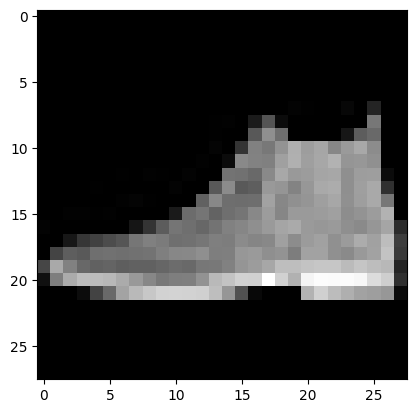

In [34]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')
    plt.imshow(x.squeeze(), cmap = 'gray')

### Задание

Попытайтесь улучшить качество распознавания, изменив функцию потерь, оптимизации, время обучения или структуру модели.
<br>Загрузите фотографию предмета одежды, приведите её к необходимому размеру и используйте обученную нейронную сеть для определения класса.

In [35]:
# Использование устройство CUDA, если оно доступно
device = "cpu"
print(f"Используется устройство: {device}")

# Создание модели
class ImprovedNetwork(nn.Module):
    def __init__(self):
        super().__init__() # Перед созданием слоёв выполняется вызов конструктора родительского класса
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),

        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model_1 = ImprovedNetwork().to(device)
print(model_1)

Используется устройство: cpu
ImprovedNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [36]:
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=1e-3)

In [37]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_1, loss_fn_1, optimizer_1)
    test(test_dataloader, model_1, loss_fn_1)
print("Done!")

Epoch 1
-------------------------------
loss: 2.280317  [    0/60000]
loss: 0.743334  [ 6400/60000]
loss: 0.433209  [12800/60000]
loss: 0.638168  [19200/60000]
loss: 0.519609  [25600/60000]
loss: 0.477136  [32000/60000]
loss: 0.449493  [38400/60000]
loss: 0.594480  [44800/60000]
loss: 0.565801  [51200/60000]
loss: 0.497533  [57600/60000]
Test Error: 
 Accuracy: 84.2%, Avg loss: 0.455767 

Epoch 2
-------------------------------
loss: 0.303595  [    0/60000]
loss: 0.422880  [ 6400/60000]
loss: 0.311720  [12800/60000]
loss: 0.457414  [19200/60000]
loss: 0.426925  [25600/60000]
loss: 0.384543  [32000/60000]
loss: 0.381856  [38400/60000]
loss: 0.535520  [44800/60000]
loss: 0.496800  [51200/60000]
loss: 0.473803  [57600/60000]
Test Error: 
 Accuracy: 85.1%, Avg loss: 0.419688 

Epoch 3
-------------------------------
loss: 0.258430  [    0/60000]
loss: 0.363071  [ 6400/60000]
loss: 0.272673  [12800/60000]
loss: 0.393675  [19200/60000]
loss: 0.364573  [25600/60000]
loss: 0.338623  [32000/600

In [38]:
torch.save(model_1.state_dict(), "model_1.pth")
print("Saved PyTorch Model State to model_1.pth")

Saved PyTorch Model State to model_1.pth


In [39]:
model_1 = ImprovedNetwork()
model_1.load_state_dict(torch.load("model_1.pth"))

<All keys matched successfully>

In [40]:
from PIL import Image
import numpy as np
import torch

def process_image_torch(path, inverse=True):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img).astype("float32") / 255.0  # [0,1]

    if inverse:
        img_array = 1.0 - img_array

    img_tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0)

    return img_array, img_tensor

Predicted: "Sandal"


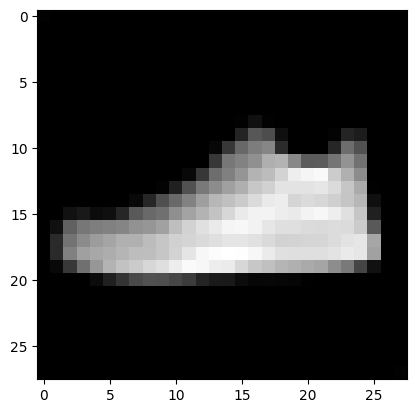

In [41]:
img_arr, img_tensor = process_image_torch("sneaker_preprocessed.jpg", inverse=False)
img_tensor = img_tensor.to(device)

model_1.eval()
with torch.no_grad():
    pred = model_1(img_tensor)
    predicted = classes[pred[0].argmax(0)]
    print(f'Predicted: "{predicted}"')
    plt.imshow(img_arr.squeeze().squeeze(), cmap = 'gray')

Predicted: "Shirt"


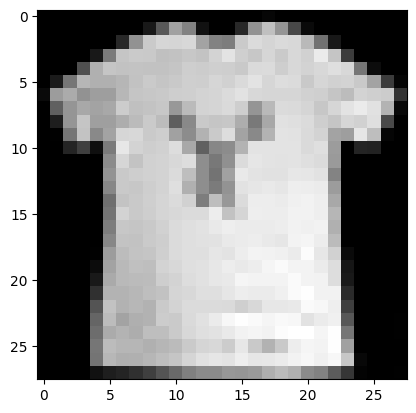

In [42]:
img_arr, img_tensor = process_image_torch("t-shirt_preprocessed.jpg", inverse=False)
img_tensor = img_tensor.to(device)

model_1.eval()
with torch.no_grad():
    pred = model_1(img_tensor)
    predicted = classes[pred[0].argmax(0)]
    print(f'Predicted: "{predicted}"')
    plt.imshow(img_arr.squeeze().squeeze(), cmap = 'gray')